# Dia 2 — Analisis de texto e imagenes con Gemini

Cuaderno de analisis de los resultados del reto del dia. Carga los dos JSON generados por los scripts y los convierte en tablas, graficos y conclusiones.

Los datos se generan antes con:

```powershell
python ejecutar_todo.py
```

Este cuaderno solo lee resultados: no llama a la API.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 170)

BASE = Path.cwd()
RUTA_TEXTO = BASE / "resultados" / "resultados_textos.json"
RUTA_IMAGEN = BASE / "resultados" / "resultados_imagenes.json"

for ruta in (RUTA_TEXTO, RUTA_IMAGEN):
    print(f"{ruta.name:28s} {'OK' if ruta.exists() else 'FALTA'}")

resultados_textos.json       OK
resultados_imagenes.json     OK


## 1. Carga de resultados

In [2]:
datos_texto = json.loads(RUTA_TEXTO.read_text(encoding="utf-8"))
datos_imagen = json.loads(RUTA_IMAGEN.read_text(encoding="utf-8"))
g_texto = datos_texto["metricas"]["global"]
g_img = datos_imagen["metricas"]["global"]

for nombre, datos in (("texto", datos_texto), ("imagen", datos_imagen)):
    m = datos["meta"]
    print(f"{nombre:6s} modelo={m['modelo']}  fecha={m['fecha']}  elementos={datos['metricas']['global'].get('textos_analizados', datos['metricas']['global'].get('imagenes_analizadas'))}")

texto  modelo=models/gemini-3.5-flash-lite  fecha=2026-09-30T11:39:33  elementos=10
imagen modelo=models/gemini-3.5-flash-lite  fecha=2026-09-30T11:41:24  elementos=5


## 2. Texto: precision global por tarea

In [3]:
df_texto_global = pd.DataFrame(
    [
        ["Deteccion de idioma", "Accuracy", g_texto["accuracy_idioma"]],
        ["Analisis de sentimiento", "Accuracy", g_texto["accuracy_sentimiento"]],
        ["Entidades nombradas", "F1", g_texto["f1_entidades"]],
        ["Resumen automatico", "F1 por palabras", g_texto["f1_resumen"]],
        ["Resumen automatico", "Similitud caracteres", g_texto["similitud_resumen"]],
    ],
    columns=["Tarea", "Metrica", "Valor"],
)
df_texto_global["Valor %"] = (df_texto_global["Valor"] * 100).round(1)
df_texto_global

,Tarea,Metrica,Valor,Valor %
0,Deteccion de idioma,Accuracy,1.00000,100.0
1,Analisis de sentimiento,Accuracy,0.80000,80.0
2,Entidades nombradas,F1,0.77987,78.0
3,Resumen automatico,F1 por palabras,0.47661,47.7
4,Resumen automatico,Similitud caracteres,0.46413,46.4


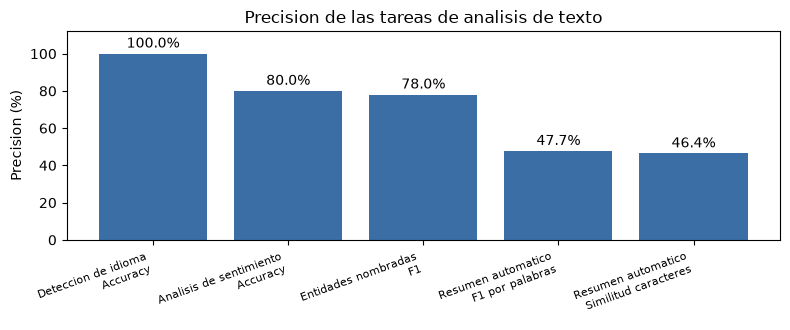

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.4))
etiquetas = df_texto_global["Tarea"] + "\n" + df_texto_global["Metrica"]
barras = ax.bar(etiquetas, df_texto_global["Valor %"], color="#3b6ea5")
ax.bar_label(barras, fmt="%.1f%%", padding=2)
ax.set_ylim(0, 112)
ax.set_ylabel("Precision (%)")
ax.set_title("Precision de las tareas de analisis de texto")
plt.xticks(rotation=20, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Texto: detalle por documento

In [5]:
df_texto = pd.DataFrame(datos_texto["metricas"]["por_texto"])
df_texto["idioma"] = df_texto["idioma"] + df_texto["idioma_ok"].map({True: " OK", False: " FALLO"})
df_texto["sentimiento"] = df_texto["sentimiento"] + df_texto["sentimiento_ok"].map({True: " OK", False: " FALLO"})
df_texto[["id", "categoria", "idioma", "sentimiento", "entidades_f1", "resumen_f1", "resumen_similitud", "compresion", "segundos"]].round(3)

,id,categoria,idioma,sentimiento,entidades_f1,resumen_f1,resumen_similitud,compresion,segundos
0,T01,noticia,es/es OK,neutro/neutro OK,0.750,0.500,0.643,0.377,17.05
1,T02,noticia,en/en OK,positivo/positivo OK,1.000,0.452,0.614,0.433,21.37
2,T03,resena,es/es OK,negativo/negativo OK,0.667,0.485,0.619,0.385,20.81
3,T04,resena,en/en OK,positivo/positivo OK,1.000,0.235,0.327,0.500,21.17
4,T05,email,es/es OK,neutro/neutro OK,0.727,0.688,0.581,0.393,21.14
5,T06,email,en/en OK,neutro/neutro OK,0.750,0.688,0.748,0.410,21.20
6,T07,noticia,fr/fr OK,neutro/positivo FALLO,0.600,0.364,0.103,0.364,21.15
7,T08,resena,de/de OK,positivo/positivo OK,0.571,0.242,0.126,0.443,20.74
8,T09,email,en/en OK,negativo/negativo OK,0.800,0.485,0.160,0.338,20.83
9,T10,noticia,es/es OK,positivo/neutro FALLO,0.933,0.629,0.721,0.426,20.92


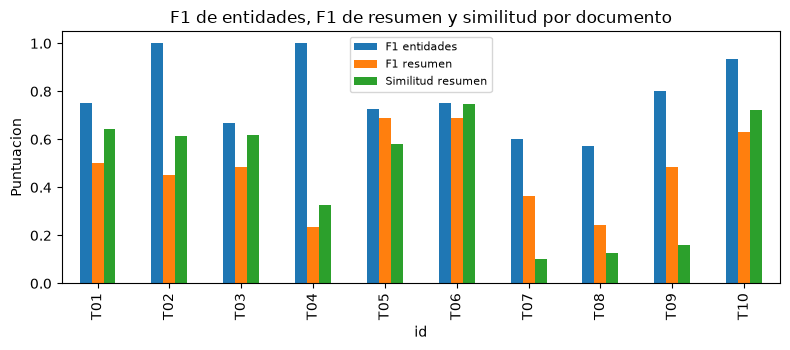

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.6))
df_texto.plot.bar(x="id", y=["entidades_f1", "resumen_f1", "resumen_similitud"], ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Puntuacion")
ax.set_title("F1 de entidades, F1 de resumen y similitud por documento")
plt.legend(["F1 entidades", "F1 resumen", "Similitud resumen"], fontsize=8)
plt.tight_layout()
plt.show()

### Matriz de confusion del sentimiento

In [7]:
pares = [(r["evaluacion"]["sentimiento"]["esperado"], r["evaluacion"]["sentimiento"]["predicho"])
         for r in datos_texto["registros"] if r["evaluacion"]]
etiquetas = sorted({e for par in pares for e in par})
matriz = pd.DataFrame(
    [[sum(1 for e, p in pares if e == fila and p == col) for col in etiquetas] for fila in etiquetas],
    index=etiquetas,
    columns=etiquetas,
)
matriz.index.name = "esperado"
matriz.columns.name = "predicho"
matriz

predicho,negativo,neutro,positivo
esperado,,,
negativo,2,0,0
neutro,0,3,1
positivo,0,1,3


### Precision por categoria de texto

In [8]:
df_cat = pd.DataFrame(datos_texto["metricas"]["por_categoria"]).T
columnas = ["accuracy_idioma", "accuracy_sentimiento", "f1_entidades", "f1_resumen"]
df_cat[columnas] = (df_cat[columnas] * 100).round(1)
df_cat

,n,accuracy_idioma,accuracy_sentimiento,f1_entidades,f1_resumen
email,3.0,100.0,100.0,75.9,62.0
noticia,4.0,100.0,50.0,82.1,48.6
resena,3.0,100.0,100.0,74.6,32.1


### Distribucion de idiomas del corpus

In [9]:
pd.Series(datos_texto["metricas"]["distribucion_idiomas"], name="textos").to_frame()

,textos
es,4
en,4
fr,1
de,1


### Entidades: gold frente a Gemini

In [10]:
for r in datos_texto["registros"]:
    if not r["evaluacion"]:
        continue
    ev = r["evaluacion"]["entidades"]
    print(f"{r['id']}  F1={ev['f1']:.2f}  (gold {ev['total_esperadas']} / detectadas {ev['total_predichas']})")
    print("   gold  :", ev["esperadas"])
    print("   gemini:", ev["predichas"])
    print()

T01  F1=0.75  (gold 6 / detectadas 10)
   gold  : ['Banco Central de Espana', 'Instituto Nacional de Estadistica', 'Madrid', 'Barcelona', 'Valencia', 'Gaspar Martinez']
   gemini: ['Banco Central de Espana', 'este lunes', 'primer trimestre', 'Instituto Nacional de Estadistica', 'Madrid', 'Barcelona', 'Valencia', 'Gaspar Martinez', 'Gobierno', 'ultimo trimestre']

T02  F1=1.00  (gold 7 / detectadas 7)
   gold  : ['Nvidia', 'Jensen Huang', 'AMD', 'Intel', 'Microsoft', 'Amazon', 'Wall Street']
   gemini: ['Nvidia', 'Jensen Huang', 'AMD', 'Intel', 'Microsoft', 'Amazon', 'Wall Street']

T03  F1=0.67  (gold 1 / detectadas 2)
   gold  : ['MediaMarkt']
   gemini: ['MediaMarkt', 'manana']

T04  F1=1.00  (gold 5 / detectadas 5)
   gold  : ['Severance', 'Adam Scott', 'Britt Lower', 'Dan Erickson', 'Apple TV+']
   gemini: ['Severance', 'Adam Scott', 'Britt Lower', 'Dan Erickson', 'Apple TV+']

T05  F1=0.73  (gold 4 / detectadas 7)
   gold  : ['Marta', 'Carlos Delgado', 'Lucia Ferrer', 'Atlas']
   

### Resumenes generados frente al resumen de referencia

In [11]:
for r in datos_texto["registros"]:
    if not r["evaluacion"]:
        continue
    ev = r["evaluacion"]["resumen"]
    print(f"{r['id']} ({r['categoria']}, {ev['palabras_originales']} palabras -> {ev['palabras_resumen']})")
    print("   gold  :", ev["esperado"])
    print("   gemini:", ev["predicho"])
    print(f"   F1 palabras={ev['f1_palabras']:.2f}  similitud={ev['similitud_caracteres']:.2f}")
    print()

T01 (noticia, 77 palabras -> 29)
   gold  : El Banco Central de Espana confirma la desaceleracion del primer trimestre, con inflacion del 2,1% y crecimiento del PIB del 0,3%, y el Gobierno aplicara estimulos fiscales en el ultimo trimestre.
   gemini: El Banco Central de Espana confirmo la desaceleracion economica con un PIB del 0,3% y una inflacion del 2,1%, mientras el ministro Gaspar Martinez anuncio estimulos fiscales.
   F1 palabras=0.50  similitud=0.64

T02 (noticia, 67 palabras -> 29)
   gold  : Nvidia registro ingresos records de 46.100 millones de dolares por la demanda de chips de IA, duplicara su inversion en centros de datos y sus acciones subieron un 8% en Wall Street.
   gemini: Nvidia reporto ingresos trimestrales record de 46.1 mil millones de dolares gracias a la demanda de chips de inteligencia artificial, impulsando un aumento del 8% en sus acciones.
   F1 palabras=0.45  similitud=0.61

T03 (resena, 65 palabras -> 25)
   gold  : El cliente devuelve un portatil con ba

## 4. Vision: precision global por tarea visual

In [12]:
df_img_global = pd.DataFrame(
    [
        ["OCR (con texto)", "Cobertura de fragmentos", g_img["ocr_cobertura_texto"]],
        ["OCR (sin texto)", "Acierto en no inventar texto", g_img["ocr_control_sin_texto"]],
        ["Descripcion de contenido", "Cobertura de conceptos", g_img["descripcion_cobertura"]],
        ["Clasificacion de escena", "Accuracy", g_img["escena_accuracy"]],
        ["Deteccion de objetos", "F1", g_img["objetos_f1"]],
    ],
    columns=["Tarea visual", "Metrica", "Valor"],
)
df_img_global["Valor %"] = (df_img_global["Valor"] * 100).round(1)
df_img_global

,Tarea visual,Metrica,Valor,Valor %
0,OCR (con texto),Cobertura de fragmentos,0.50000,50.0
1,OCR (sin texto),Acierto en no inventar texto,1.00000,100.0
2,Descripcion de contenido,Cobertura de conceptos,0.92000,92.0
3,Clasificacion de escena,Accuracy,0.80000,80.0
4,Deteccion de objetos,F1,0.60432,60.4


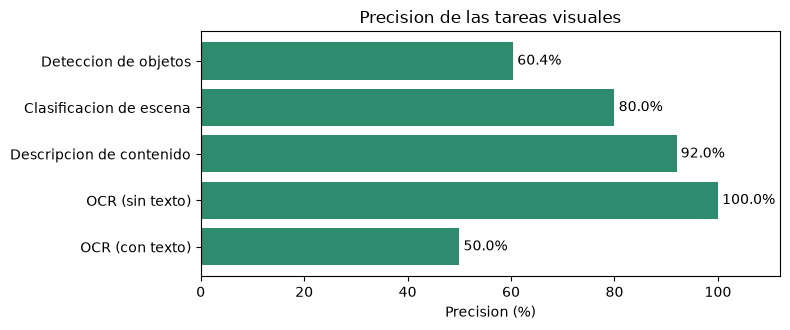

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.4))
barras = ax.barh(df_img_global["Tarea visual"], df_img_global["Valor %"], color="#2e8b6e")
ax.bar_label(barras, fmt="%.1f%%", padding=3)
ax.set_xlim(0, 112)
ax.set_xlabel("Precision (%)")
ax.set_title("Precision de las tareas visuales")
plt.tight_layout()
plt.show()

## 5. Vision: detalle por imagen

In [14]:
df_img = pd.DataFrame(datos_imagen["metricas"]["por_imagen"])
df_img[["id", "tipo", "ocr", "ocr_modo", "descripcion", "escena_texto", "objetos_f1", "segundos"]].round(3)

,id,tipo,ocr,ocr_modo,descripcion,escena_texto,objetos_f1,segundos
0,01_teatro_griego_taormina.jpg,foto de paisaje con monumento,1.0,sin texto (control),0.8,paisaje/paisaje,0.769,22.24
1,02_tipos_fracturas_hueso.jpg,diagrama medico con etiquetas,1.0,cobertura de fragmentos,1.0,grafico/grafico,0.286,22.00
2,03_perro_pastor_aleman.jpg,foto de animal,1.0,sin texto (control),0.8,animal/animal,0.500,22.29
3,04_hamburguesa.jpg,producto / comida,1.0,sin texto (control),1.0,producto/producto,0.800,22.11
4,05_molecula_3d.jpg,render 3D / ilustracion,0.0,cobertura de fragmentos,1.0,otro/grafico,0.667,22.11


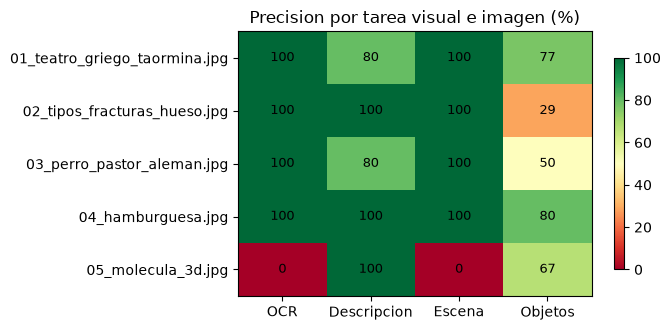

In [15]:
mapa = df_img.set_index("id")[["ocr", "descripcion", "escena", "objetos_f1"]] * 100
mapa.columns = ["OCR", "Descripcion", "Escena", "Objetos"]

fig, ax = plt.subplots(figsize=(7, 3.4))
imagen = ax.imshow(mapa.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(mapa.columns)), mapa.columns)
ax.set_yticks(range(len(mapa.index)), mapa.index)
for i in range(mapa.shape[0]):
    for j in range(mapa.shape[1]):
        ax.text(j, i, f"{mapa.values[i, j]:.0f}", ha="center", va="center", fontsize=9)
ax.set_title("Precision por tarea visual e imagen (%)")
fig.colorbar(imagen, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### OCR: fragmentos detectados y texto inventado

In [16]:
for r in datos_imagen["registros"]:
    o = r["evaluacion"]["ocr"]
    if o["hay_texto_esperado"]:
        faltan = [f for f in o["fragmentos_esperados"] if f not in o["fragmentos_detectados"]]
        print(f"{r['id']}  cobertura={o['puntuacion'] * 100:.0f}%")
        print("   esperados :", o["fragmentos_esperados"])
        print("   no leidos :", faltan or "ninguno")
        print("   transcrito:", o["texto_transcrito"][:200])
    else:
        veredicto = "INVENTO TEXTO" if o["texto_inventado"] else "correcto: no hay texto"
        print(f"{r['id']}  {veredicto}  (transcrito: {o['texto_transcrito']!r})")
    print()

01_teatro_griego_taormina.jpg  correcto: no hay texto  (transcrito: '')

02_tipos_fracturas_hueso.jpg  cobertura=100%
   esperados : ['Normal', 'Transverse', 'Oblique', 'Spiral', 'Comminuted', 'Impacted', 'Segmental', 'Torus', 'Greenstick']
   no leidos : ninguno
   transcrito: Normal Transverse Oblique Spiral Comminuted Avulsed Segmental Impacted Torus Greenstick

03_perro_pastor_aleman.jpg  correcto: no hay texto  (transcrito: '')

04_hamburguesa.jpg  correcto: no hay texto  (transcrito: '')

05_molecula_3d.jpg  cobertura=0%
   esperados : ['pngtree', 'PNG']
   no leidos : ['pngtree', 'PNG']
   transcrito: 



### Deteccion de objetos: gold frente a Gemini

In [17]:
for r in datos_imagen["registros"]:
    o = r["evaluacion"]["objetos"]
    print(f"{r['id']}  P={o['precision']:.2f}  R={o['recall']:.2f}  F1={o['f1']:.2f}")
    print("   gold  :", o["esperados"])
    print("   gemini:", o["predichos"])
    print()

01_teatro_griego_taormina.jpg  P=0.71  R=0.83  F1=0.77
   gold  : ['anfiteatro', 'edificios', 'arboles', 'mar', 'playa', 'nubes']
   gemini: ['anfiteatro', 'mar', 'edificio', 'playa', 'arbol', 'cielo', 'reja']

02_tipos_fracturas_hueso.jpg  P=1.00  R=0.17  F1=0.29
   gold  : ['huesos', 'femur', 'rotula', 'etiquetas', 'flechas', 'imagenes medicas']
   gemini: ['hueso']

03_perro_pastor_aleman.jpg  P=1.00  R=0.33  F1=0.50
   gold  : ['perro', 'hierba', 'exterior']
   gemini: ['perro']

04_hamburguesa.jpg  P=0.86  R=0.75  F1=0.80
   gold  : ['hamburguesa', 'pan', 'carne', 'queso', 'bacon', 'lechuga', 'tomate', 'salsa']
   gemini: ['hamburguesa', 'pan', 'carne', 'queso', 'tocino', 'lechuga', 'salsa']

05_molecula_3d.jpg  P=1.00  R=0.50  F1=0.67
   gold  : ['molecula', 'esferas', 'burbujas', 'modelo 3d']
   gemini: ['molecula', 'burbuja']



### Descripciones generadas y conceptos que faltan

In [18]:
for r in datos_imagen["registros"]:
    d = r["evaluacion"]["descripcion"]
    print(f"{r['id']}  cobertura={d['cobertura'] * 100:.0f}%")
    print(" ", d["predicho"])
    print("  elementos:", d["elementos_clave"])
    print("  faltan   :", d["conceptos_faltantes"] or "ninguno")
    print()

01_teatro_griego_taormina.jpg  cobertura=80%
  Fotografia panoramica que muestra las ruinas de un anfiteatro romano antiguo en primer plano, con composicion diagonal. Al fondo se observa una playa de arena dorada y un mar azul turquesa brillante bajo un cielo despejado. Destacan los tonos azul, ocre y verde.
  elementos: ['anfiteatro romano', 'playa', 'mar', 'ruinas', 'costa', 'cielo']
  faltan   : ['cerro con edificios']

02_tipos_fracturas_hueso.jpg  cobertura=100%
  Imagen ilustrativa y educativa que muestra diferentes tipos de fracturas óseas en dos filas sobre fondo blanco. Predominan los tonos gris, blanco y rojo. Presenta esquemas de huesos con etiquetas de texto en inglés para cada lesión, organizados de manera clara y simétrica.
  elementos: ['fracturas óseas', 'huesos', 'ilustración médica', 'etiquetas de texto', 'fondo blanco', 'esquemas']
  faltan   : ninguno

03_perro_pastor_aleman.jpg  cobertura=80%
  Fotografia a color que muestra un perro pastor aleman tumbado sobre un 

## 6. Comparativa global texto frente a vision

In [19]:
comparativa = pd.DataFrame(
    [
        ["Idioma", "texto", g_texto["accuracy_idioma"]],
        ["Sentimiento", "texto", g_texto["accuracy_sentimiento"]],
        ["Entidades", "texto", g_texto["f1_entidades"]],
        ["Resumen", "texto", g_texto["f1_resumen"]],
        ["OCR", "vision", g_img["ocr"]],
        ["Descripcion", "vision", g_img["descripcion_cobertura"]],
        ["Escena", "vision", g_img["escena_accuracy"]],
        ["Objetos", "vision", g_img["objetos_f1"]],
    ],
    columns=["Tarea", "Modalidad", "Precision"],
)
comparativa["Precision %"] = (comparativa["Precision"] * 100).round(1)
comparativa.sort_values("Precision", ascending=False)

,Tarea,Modalidad,Precision,Precision %
0,Idioma,texto,1.00000,100.0
5,Descripcion,vision,0.92000,92.0
4,OCR,vision,0.80000,80.0
1,Sentimiento,texto,0.80000,80.0
6,Escena,vision,0.80000,80.0
2,Entidades,texto,0.77987,78.0
7,Objetos,vision,0.60432,60.4
3,Resumen,texto,0.47661,47.7


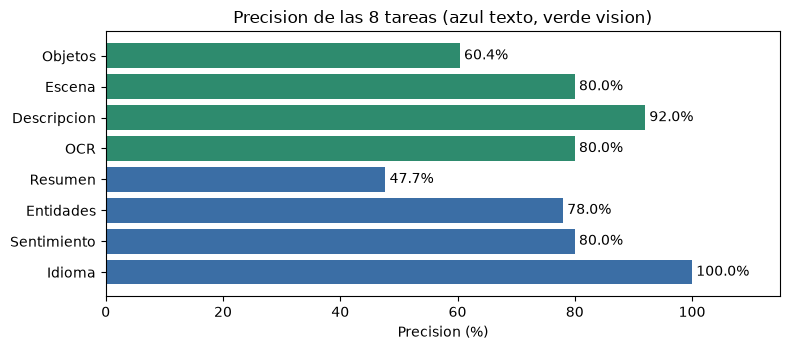

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.6))
colores = ["#3b6ea5" if m == "texto" else "#2e8b6e" for m in comparativa["Modalidad"]]
barras = ax.barh(comparativa["Tarea"], comparativa["Precision %"], color=colores)
ax.bar_label(barras, fmt="%.1f%%", padding=3)
ax.set_xlim(0, 115)
ax.set_xlabel("Precision (%)")
ax.set_title("Precision de las 8 tareas (azul texto, verde vision)")
plt.tight_layout()
plt.show()

## 7. Coste, latencia y fiabilidad de la salida

Llamadas a la API   : 60 (40 texto + 20 vision), 4 por elemento
Errores de API      : 0
Latencia por texto  : 20.6 s (4 llamadas en serie)
Latencia por imagen : 22.1 s (4 llamadas en serie)


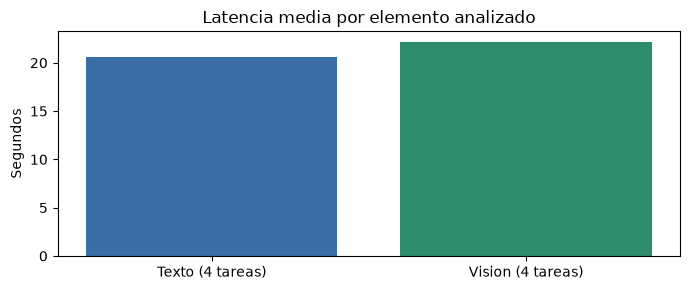

In [21]:
llamadas_texto = len(datos_texto["registros"]) * 4
llamadas_imagen = len(datos_imagen["registros"]) * 4
errores = sum(1 for r in datos_texto["registros"] + datos_imagen["registros"] if r["error"])

print(f"Llamadas a la API   : {llamadas_texto + llamadas_imagen} ({llamadas_texto} texto + {llamadas_imagen} vision), 4 por elemento")
print(f"Errores de API      : {errores}")
print(f"Latencia por texto  : {g_texto['segundos_medio']:.1f} s (4 llamadas en serie)")
print(f"Latencia por imagen : {g_img['segundos_medio']:.1f} s (4 llamadas en serie)")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(["Texto (4 tareas)", "Vision (4 tareas)"], [g_texto["segundos_medio"], g_img["segundos_medio"]], color=["#3b6ea5", "#2e8b6e"])
ax.set_ylabel("Segundos")
ax.set_title("Latencia media por elemento analizado")
plt.tight_layout()
plt.show()

## 8. Conclusiones

In [22]:
mejor_texto = df_texto_global.loc[df_texto_global["Valor"].idxmax()]
peor_texto = df_texto_global.loc[df_texto_global["Valor"].idxmin()]
mejor_img = df_img_global.loc[df_img_global["Valor"].idxmax()]
peor_img = df_img_global.loc[df_img_global["Valor"].idxmin()]
media_texto = (g_texto["accuracy_idioma"] + g_texto["accuracy_sentimiento"] + g_texto["f1_entidades"] + g_texto["f1_resumen"]) / 4
media_vision = (g_img["ocr"] + g_img["descripcion_cobertura"] + g_img["escena_accuracy"] + g_img["objetos_f1"]) / 4
peor_objetos = df_img.loc[df_img["objetos_f1"].idxmin()]

# Imagenes donde el modelo lista menos objetos de los esperados: el fallo de granularidad.
granos = []
for r in datos_imagen["registros"]:
    o = r["evaluacion"]["objetos"]
    if o["total_predichos"] < o["total_esperados"]:
        granos.append(f"{r['id']} ({o['total_predichos']}/{o['total_esperados']} objetos)")

print("=== Resumen de la practica ===")
print()
print(f"Texto  -> mejor: {mejor_texto['Tarea']} ({mejor_texto['Valor %']}%) | peor: {peor_texto['Tarea']} ({peor_texto['Valor %']}%)")
print(f"Vision -> mejor: {mejor_img['Tarea visual']} ({mejor_img['Valor %']}%) | peor: {peor_img['Tarea visual']} ({peor_img['Valor %']}%)")
print(f"Media texto {media_texto * 100:.1f}% | media vision {media_vision * 100:.1f}%")
print()
print("1. La salida JSON con response_schema es fiable:", llamadas_texto + llamadas_imagen, "llamadas,", errores, "errores.")
print("   Ni una sola respuesta llego como texto libre, asi que no hubo que limpiar nada con regex.")
print()
print("2. Las tareas de clasificacion (idioma, sentimiento, escena) son las mas solidas, con un")
print("   80-100%: son categorias cerradas y el modelo elige entre pocas opciones.")
print()
print("3. El OCR es bueno donde hay que leer y correcto donde no hay que hacerlo: leo las 9")
print("   etiquetas inglesas del diagrama medico al 100%, y en las 3 fotos sin texto no inventa")
print("   nada. Lo que falla es la marca de agua 'pngtree' de la imagen de la molecula, que")
print("   el modelo ignora por completo. Es el punto debil del OCR de este lote.")
print()
print("4. La deteccion de objetos es la tarea mas floja (F1", round(g_img["objetos_f1"] * 100), "%),")
print("   con precision", round(g_img["objetos_precision"] * 100), "% y recall", round(g_img["objetos_recall"] * 100), "%.")
print("   No inventa objetos: lo que hace es devolver el inventario demasiado grueso.")
if granos:
    print("   En", len(granos), "imagen(es) lista menos objetos de los esperados:")
    for g in granos:
        print("     -", g)
print("   El caso peor es", peor_objetos["id"], "con F1", round(peor_objetos["objetos_f1"] * 100), "%,")
print("   aunque en su descripcion detalle todos los ingredientes, etiquetas o fracturas.")
print("   Es un problema de granularidad del prompt, no de capacidad visual.")
print()
print("5. Los fallos de sentimiento y de escena estan en noticias y en imagenes con categoria")
print("   discutible, y se dejan sin corregir: son puntos donde la referencia y el modelo son")
print("   defendibles los dos. Ajustarlos seria falsear la medida.")
print()
print("6. Ojo con la reproducibilidad: la deteccion de objetos es la tarea inestable. Con el")
print("   mismo prompt, la misma imagen y temperature=0, puede devolver 1 objeto o 7.")
print()
print("7. El limite practico es la cuota: 15 peticiones por minuto en la capa gratuita obliga a")
print("   espacionar las llamadas (GEMINI_RPM en comun.py) y limita el tamano del lote.")


=== Resumen de la practica ===

Texto  -> mejor: Deteccion de idioma (100.0%) | peor: Resumen automatico (46.4%)
Vision -> mejor: OCR (sin texto) (100.0%) | peor: OCR (con texto) (50.0%)
Media texto 76.4% | media vision 78.1%

1. La salida JSON con response_schema es fiable: 60 llamadas, 0 errores.
   Ni una sola respuesta llego como texto libre, asi que no hubo que limpiar nada con regex.

2. Las tareas de clasificacion (idioma, sentimiento, escena) son las mas solidas, con un
   80-100%: son categorias cerradas y el modelo elige entre pocas opciones.

3. El OCR es bueno donde hay que leer y correcto donde no hay que hacerlo: leo las 9
   etiquetas inglesas del diagrama medico al 100%, y en las 3 fotos sin texto no inventa
   nada. Lo que falla es la marca de agua 'pngtree' de la imagen de la molecula, que
   el modelo ignora por completo. Es el punto debil del OCR de este lote.

4. La deteccion de objetos es la tarea mas floja (F1 60 %),
   con precision 91 % y recall 52 %.
   No inv